# Threshold baseline

In [2]:
%load_ext autoreload
%autoreload 2

import aribu            # GDAL fix, please keep this as the first import

import json
import platform
import time
import warnings
from pprint import pprint
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import skimage
from shapely.geometry import box
from skimage.filters import threshold_otsu

from aribu.paths import *
from aribu.dataset import *
from aribu.baseline import *
from aribu.viz import *
from aribu.metrics import *
from aribu.report import *

The number of chips in each split:

In [3]:
splits = load_splits()
train, val = splits["train"], splits["val"]

for name, chips in splits.items():
    print(f"{name:<8} {len(chips):>4} chips")

train     252 chips
val        89 chips
test       90 chips
bolivia    15 chips


## 1. Global threshold

The first candidate of our baseline model: pick an optimal `THRESHOLD_DB` such that the predictor `X < THRESHOLD_DB` gives the best (micro) IoU score for the training split. Recall that the micro version of a score is calculated from pixels pooled over all chips in the split, whereas the macro version is obtained by first calculating the score for each chip and then take the average.

In [4]:
BASE = {"speckle_filter_size": 0, "clip_db": (CLIP_LO, CLIP_HI)}

thresholds = np.arange(-28, -15.5, 0.5)
t0 = time.perf_counter()
sweep = pd.DataFrame([
    {"threshold_db": t, **evaluate(make_baseline_predictor({**BASE, "threshold_db": t}), train)["micro"]}
    for t in thresholds
])
print(f"{len(thresholds)} thresholds x {len(train)} train chips "
      f"in {time.perf_counter() - t0:.0f}s")

THRESHOLD_DB = float(sweep.loc[sweep["iou"].idxmax(), "threshold_db"])          # pyright: ignore[reportArgumentType]
print(f"\nbest train IoU {sweep['iou'].max():.3f} at {THRESHOLD_DB:.1f} dB")
sweep.round(3)

25 thresholds x 252 train chips in 131s

best train IoU 0.465 at -23.5 dB


,threshold_db,iou,f1,precision,recall,accuracy,specificity
0,-28.0,0.324,0.489,0.851,0.343,0.932,0.994
1,-27.5,0.349,0.517,0.839,0.374,0.934,0.992
2,-27.0,0.373,0.543,0.825,0.405,0.935,0.991
3,-26.5,0.396,0.567,0.809,0.437,0.937,0.989
4,-26.0,0.416,0.588,0.790,0.468,0.938,0.987
5,-25.5,0.434,0.605,0.768,0.499,0.938,0.984
6,-25.0,0.448,0.619,0.744,0.530,0.938,0.981
7,-24.5,0.458,0.629,0.717,0.560,0.937,0.977
8,-24.0,0.464,0.634,0.687,0.588,0.935,0.972
9,-23.5,0.465,0.635,0.655,0.616,0.933,0.966


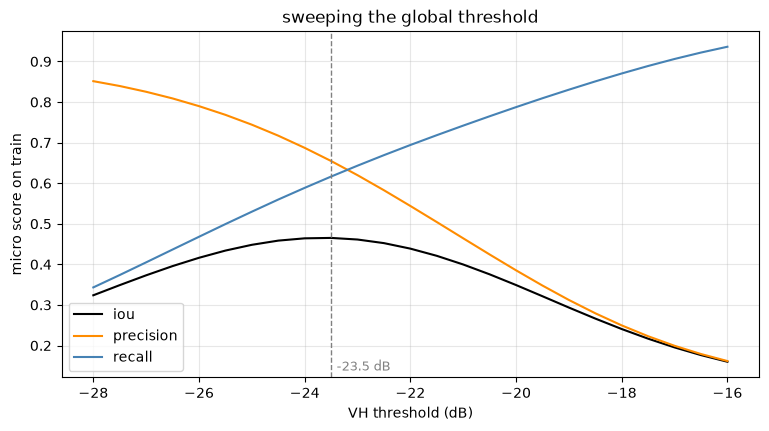

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for key, colour in (("iou", "black"), ("precision", "darkorange"), ("recall", "steelblue")):
    ax.plot(sweep["threshold_db"], sweep[key], color=colour, label=key)

ax.axvline(THRESHOLD_DB, color="grey", linestyle="--", linewidth=1)
ax.annotate(f"{THRESHOLD_DB:.1f} dB", (THRESHOLD_DB, 0), xycoords=("data", "axes fraction"),
            xytext=(4, 5), textcoords="offset points", fontsize=9, color="grey")

ax.set_xlabel("VH threshold (dB)")
ax.set_ylabel("micro score on train")
ax.set_title("sweeping the global threshold")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Let's save this candidate baseline model as `global_thr` and record its performance on the validation split:

In [6]:
global_thr = make_baseline_predictor({**BASE, "threshold_db": THRESHOLD_DB})
r_global = evaluate(global_thr, val, "1. global")

pprint(r_global["micro"])

{'accuracy': 0.9294590047999044,
 'f1': 0.6611440070265707,
 'iou': 0.49381263593424546,
 'precision': 0.7013343587964883,
 'recall': 0.6253102582190977,
 'specificity': 0.967070292504307}


## 2. Global threshold + speckle filter

Radar images are grainy: neighbouring pixels of the same surface come back with wildly different brightness. This is *speckle*, an interference effect. These dark pixes are outliers and will be classified as water by `global_thr`.

Solution: using a 5x5 median filter replaces each pixel with the median of its neighbourhood, which kills the speckles. This involves a helper function `median_filter_db` that handels the missing values properly (this helper function is called by another hepler `make_baseline_predictor` which we actually call).

In [7]:
SPECKLE = 5

speckle_thr = make_baseline_predictor(
    {**BASE, "speckle_filter_size": SPECKLE, "threshold_db": THRESHOLD_DB})
r_speckle = evaluate(speckle_thr, val, "2. global + speckle")

pprint(r_speckle["micro"])

{'accuracy': 0.9411121667518161,
 'f1': 0.6998521007947037,
 'iou': 0.5382865297267195,
 'precision': 0.7969662806190427,
 'recall': 0.6238348229612147,
 'specificity': 0.980346947738252}


## 3. Per-chip Otsu + speckle filter

The third candidate: applying the speckle filter, then using `threshold_otsu` on each chip.

In [8]:
def otsu_thr(vv, vh, valid):
    x = np.clip(median_filter_db(vh, valid, SPECKLE), CLIP_LO, CLIP_HI)
    return x < threshold_otsu(x[valid])

r_otsu = evaluate(otsu_thr, val, "3. per-chip Otsu + speckle")

pprint(r_otsu["micro"])

{'accuracy': 0.7167385134787868,
 'f1': 0.3844868777801393,
 'iou': 0.2379967531627472,
 'precision': 0.2526649741366329,
 'recall': 0.8039051526394246,
 'specificity': 0.7059594141711211}


This is the **worst** so far.

## 4. The dataset's own weak labels

The Sen1Floods11 dataset contains `S1OtsuLabelHand`: water masks the authors produced with their own Otsu pipeline (their Otsu thresholds are determined **per event**). Let's regard this as the fourth option for the baseline and see how it performs.

This predictor depends on the identity of each chip it looks at, so `evaluate_with_chip_id` is necessary.

In [9]:
def weak_label(chip_id):
    with rasterio.open(OTSU_DIR / f"{chip_id}_S1OtsuLabelHand.tif") as src:
        weak = src.read(1)
    return lambda vv, vh, valid: weak == LABEL_WATER

r_weak = evaluate_with_chip_id(weak_label, val, "4. weak label")

pprint(r_weak["micro"])

{'accuracy': 0.9232589433818053,
 'f1': 0.6725619241958947,
 'iou': 0.5066616186886799,
 'precision': 0.6339754246332938,
 'recall': 0.7161499207155233,
 'specificity': 0.9488702178823549}


## 5. Comparison

In [10]:
compare(r_global, r_speckle, r_otsu, r_weak)

,iou (micro),f1 (micro),precision (micro),recall (micro),accuracy (micro),iou (macro),f1 (macro)
1. global,0.4938,0.6611,0.7013,0.6253,0.9295,0.2805,0.3736
2. global + speckle,0.5383,0.6999,0.7970,0.6238,0.9411,0.3034,0.3892
3. per-chip Otsu + speckle,0.2380,0.3845,0.2527,0.8039,0.7167,0.2695,0.3322
4. weak label,0.5067,0.6726,0.6340,0.7161,0.9233,0.3189,0.4049


Focusing on the micro IoU score, global + speckle filter is the winner (but weak label is pretty close and the best for the macro scores).

In [11]:
for r in (r_global, r_speckle, r_otsu, r_weak):
    print(f"{r['name']:<28} {r['seconds']:>5.1f}s over {r['n_chips']} chips")

1. global                      3.3s over 86 chips
2. global + speckle           14.9s over 86 chips
3. per-chip Otsu + speckle    15.0s over 86 chips
4. weak label                  2.6s over 86 chips


Applying the speckle filter costs extra ~13 seconds.

Note that 3 of the validation chips have no valid pixels at all, hence the count is 86 instead of 89.

### Visualizing the errors

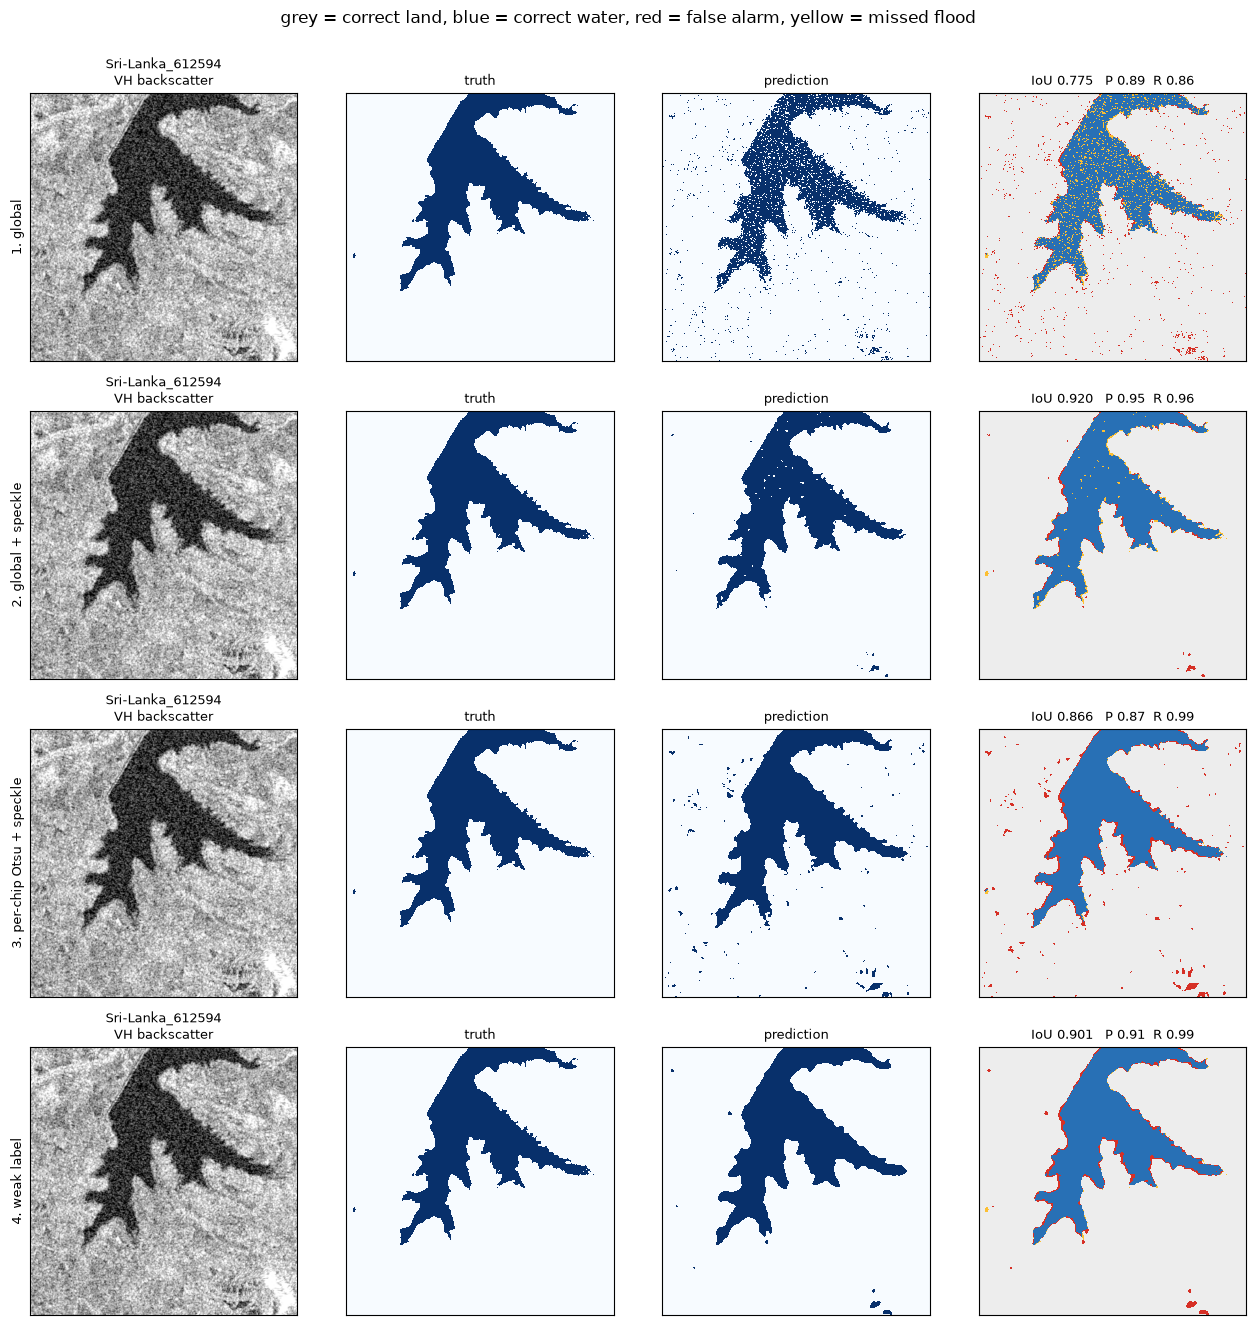

In [12]:
chip_id = "Sri-Lanka_612594"
models = [(r_global["name"], global_thr), (r_speckle["name"], speckle_thr),
          (r_otsu["name"], otsu_thr), (r_weak["name"], weak_label(chip_id))]

fig, axes = plt.subplots(len(models), 4, figsize=(13, 3.3 * len(models)))

for row, (name, predict) in zip(axes, models, strict=True):
    error_panel(chip_id, predict, row)
    row[0].set_ylabel(name, fontsize=9)

fig.suptitle("grey = correct land, blue = correct water, "
             "red = false alarm, yellow = missed flood", y=1)
fig.tight_layout()
plt.show()

Now a chip that is mostly dry land, focusing on global + speckle vs per-chip Otsu + speckle:

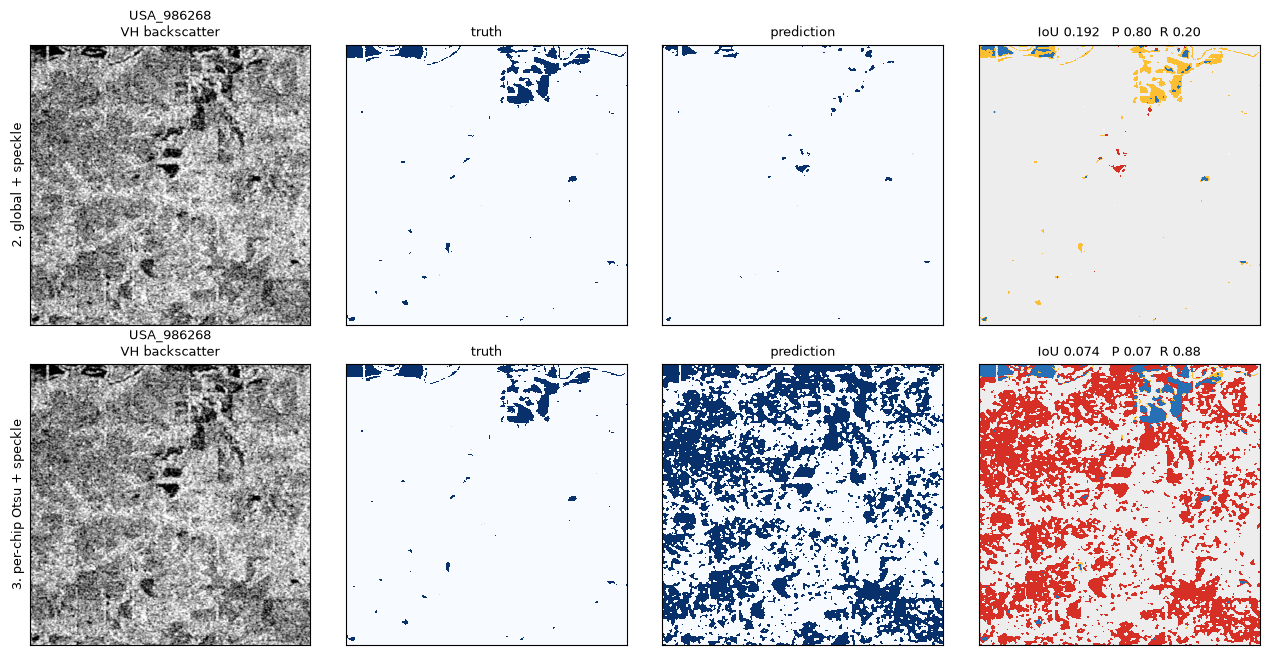

In [13]:
chip_id = "USA_986268"
models = [(r_speckle["name"], speckle_thr), (r_otsu["name"], otsu_thr)]

fig, axes = plt.subplots(len(models), 4, figsize=(13, 3.3 * len(models)))

for row, (name, predict) in zip(axes, models, strict=True):
    error_panel(chip_id, predict, row)
    row[0].set_ylabel(name, fontsize=9)

fig.tight_layout()
plt.show()

Per-chip Otsu produced **a lot of** false positives!

## 6. Freezing the baseline

We now pick a winner according to the micro IoU scores on the validation split and then record its config (in case it has one, and we know it does). This will be our choice of baseline model.

In [14]:
CONFIGS = {
    r_global["name"]:  {**BASE, "threshold_db": THRESHOLD_DB},
    r_speckle["name"]: {**BASE, "speckle_filter_size": SPECKLE, "threshold_db": THRESHOLD_DB},
}           # the other two canditates do not need a config

on_val = {r["name"]: r["micro"]["iou"] for r in (r_global, r_speckle, r_otsu, r_weak)}
winner = max(on_val, key=on_val.get)          # pyright: ignore[reportCallIssue, reportArgumentType]
if winner not in CONFIGS:              # Otsu and the weak labels involve no config
    raise ValueError(f"{winner!r} wins on val but is not built from a config")

BASELINE_CONFIG = {"model": "vh-threshold", "band": "VH", **CONFIGS[winner],
                   "tuned_on": "train", "selected_on": "val", "selection_metric": "micro_iou"}
baseline = make_baseline_predictor(BASELINE_CONFIG)

print(f"frozen: {winner}   (val micro IoU {on_val[winner]:.4f})")
pprint(BASELINE_CONFIG)

frozen: 2. global + speckle   (val micro IoU 0.5383)
{'band': 'VH',
 'clip_db': (-50.0, 1.0),
 'model': 'vh-threshold',
 'selected_on': 'val',
 'selection_metric': 'micro_iou',
 'speckle_filter_size': 5,
 'threshold_db': -23.5,
 'tuned_on': 'train'}


Its performance across all splits:

In [15]:
final = {name: evaluate(baseline, chips, f"baseline / {name}") for name, chips in splits.items()}

for name, r in final.items():
    print(f"{name:<8} {r['n_chips']:>3} chips   micro IoU {r['micro']['iou']:.4f}   "
          f"macro IoU {r['macro']['iou']:.4f}   P {r['micro']['precision']:.3f}   "
          f"R {r['micro']['recall']:.3f}   ({r['seconds']:.0f}s)")

train    251 chips   micro IoU 0.5111   macro IoU 0.2863   P 0.757   R 0.612   (42s)
val       86 chips   micro IoU 0.5383   macro IoU 0.3034   P 0.797   R 0.624   (15s)
test      88 chips   micro IoU 0.5902   macro IoU 0.3142   P 0.822   R 0.677   (16s)
bolivia   15 chips   micro IoU 0.5951   macro IoU 0.3544   P 0.922   R 0.627   (2s)


Surprisingly, it got the best micro IoU on the held-out split (Bolivia).

Let's save all the relevant info of the baseline into a JSON file.

In [16]:
VERSIONS = {"python": platform.python_version(), "numpy": np.__version__,
            "pandas": pd.__version__, "rasterio": rasterio.__version__,
            "scikit-image": skimage.__version__}          # pyright: ignore[reportAttributeAccessIssue]

report = {
    "notebook": "02_threshold-baseline",
    "created": pd.Timestamp.now().isoformat(timespec="seconds"),
    "config": BASELINE_CONFIG,
    "versions": VERSIONS,
    "headline": {"split": "test", "micro_iou": final["test"]["micro"]["iou"],
                 "macro_iou": final["test"]["macro"]["iou"]},
    "splits": {name: {"n_chips": r["n_chips"], "counts": r["counts"],
                      "micro": r["micro"], "macro": r["macro"]}
               for name, r in final.items()},
}
saved = write_json(RESULTS_DIR / "baseline.json", report)

if saved["config"] != json_safe(BASELINE_CONFIG):
    raise ValueError("the saved config is not the one we froze")            # might be too cautious, but it doesn't hurt

print(f"wrote {RESULTS_DIR / 'baseline.json'}")
print(f"\nTHE NUMBER TO BEAT: micro IoU {saved['headline']['micro_iou']:.4f} on test")

wrote C:\Dev\Projects\Aribu\data\results\baseline.json

THE NUMBER TO BEAT: micro IoU 0.5902 on test


## 7. Constants for notebook 03

A U-Net needs a input with (roughly) zero mean and unit std, therefore it requires normalization as one of the preprocessing step. I order to avoid data leakage, we calculate and save these statistics from the **train split only**.

In [17]:
def band_moments(chip_ids):
    """Returns the mean, std, and number of valid pixels per band for the given chips."""
    n, s, ss = (np.zeros(2, np.float64) for _ in range(3))
    for chip_id in chip_ids:            # we stream rather than stacking all pixels at once for memory efficiency
        c = load_chip(chip_id)
        v = valid_mask(c)
        if not v.any():
            continue
        for i, band in enumerate((c.vv, c.vh)):
            px = np.clip(band[v], CLIP_LO, CLIP_HI).astype(np.float64)
            n[i] += px.size
            s[i] += px.sum()
            ss[i] += np.square(px).sum()
    mean = s / n
    return mean, np.sqrt(ss / n - mean ** 2), n


t0 = time.perf_counter()
mean, std, n_px = band_moments(train)

# just to show how fast streaming is:
print(f"{int(n_px[0]):,} valid pixels per band, streamed through in merely {time.perf_counter() - t0:.0f}s\n")
print(pd.DataFrame({"mean": mean, "std": std}, index=["VV", "VH"]).round(4).to_string())

NORM = {"mean": mean.tolist(), "std": std.tolist(), "clip": [CLIP_LO, CLIP_HI],
        "computed_on": "train", "n_pixels_per_band": int(n_px[0])}
write_json(RESULTS_DIR / "norm_stats.json", NORM)
print(f"\nwrote {RESULTS_DIR / 'norm_stats.json'} -- load this, do not recompute it")

57,279,257 valid pixels per band, streamed through in merely 6s

       mean     std
VV -10.4549  4.0395
VH -17.3157  4.7841

wrote C:\Dev\Projects\Aribu\data\results\norm_stats.json -- load this, do not recompute it
